# Exact Diagonalization

Exact diagonalization is a numerical method that involves directly solving for the eigenvalues and eigenvectors of the Hamiltonian. In this instance, we will use this method to understand the $k$ interaction by turning off the the $J$ and $h$ parameters:

$$ \mathcal{H_k} = \sum_i k_R(\sigma_i^x \sigma_{i+2}^y- \sigma_i^z\sigma_{i+1}^y\sigma_{i+2}^x)+k_L(\sigma_i^x\sigma_{i+1}^y\sigma_{i+2}^z - \sigma_{i}^y\sigma_{i+2}^x) $$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as lg

In [5]:
def H_k(k_left, k_right, L):

    # operators
    I = np.eye(2)
    X = np.array([[0, 1], [1, 0]])
    Y = np.array([[0, -1j], [1j, 0]])
    Z = np.array([[1, 0], [0, -1]])

    # define my hamiltonian
    H = np.zeros((2**L, 2**L), dtype=complex)

    # XIY interaction
    for i in range(L):
        op = 1
        for j in range(L):
            if j == i:
                op = np.kron(op, X)
            elif j == i+2 % L:
                op = np.kron(op, Y)
            else:
                op = np.kron(op, I)
        H += k_right * op
        
    # YX interaction
    for i in range(L):
        op = 1
        for j in range(L):
            if j == i:
                op = np.kron(op, Y)
            elif j == i+2 % L:
                op = np.kron(op, X)
            else:
                op = np.kron(op, I)
        H -= k_left * op

    # XYZ interaction
    for i in range(L):
        op = 1
        for j in range(L):
            if j == i:
                op = np.kron(op, X)
            elif j == i+1 % L:
                op = np.kron(op, Y)
            elif j == i+2 % L:
                op = np.kron(op, Z)
            else:
                op = np.kron(op, I)
        H += k_left * op

    # ZYX interaction
    for i in range(L):
        op = 1
        for j in range(L):
            if j == i:
                op = np.kron(op, Z)
            elif j == i+1 % L:
                op = np.kron(op, Y)
            elif j == i+2 % L:
                op = np.kron(op, X)
            else:
                op = np.kron(op, I)
        H -= k_right * op

    return H

In [ ]:
def Ham(J_x, h_z, k_left, k_right, L):

    # Pauli matrices in sparse form
    I = sp.eye(2, format="csr", dtype=complex)
    X = sp.csr_matrix([[0, 1], [1, 0]], dtype=complex)
    Y = sp.csr_matrix([[0, -1j], [1j, 0]], dtype=complex)
    Z = sp.csr_matrix([[1, 0], [0, -1]], dtype=complex)

    H = sp.csr_matrix((2**L, 2**L), dtype=complex)

    def kron_all(ops):
        out = ops[0]
        for op in ops[1:]:
            out = sp.kron(out, op, format="csr")
        return out

    for i in range(L):
        # XX
        ops = []
        for j in range(L):
            if j == i:
                ops.append(X)
            elif j == (i + 1) % L:
                ops.append(X)
            else:
                ops.append(I)
        H += J_x * kron_all(ops)

        # Z
        ops = []
        for j in range(L):
            if j == i:
                ops.append(Z)
            else:
                ops.append(I)
        H += h_z * kron_all(ops)
        
        # XIY
        ops = []
        for j in range(L):
            if j == i:
                ops.append(X)
            elif j == (i + 2) % L:
                ops.append(Y)
            else:
                ops.append(I)
        H += k_right * kron_all(ops)

        # YX
        ops = []
        for j in range(L):
            if j == i:
                ops.append(Y)
            elif j == (i + 2) % L:
                ops.append(X)
            else:
                ops.append(I)
        H -= k_left * kron_all(ops)

        # XYZ
        ops = []
        for j in range(L):
            if j == i:
                ops.append(X)
            elif j == (i + 1) % L:
                ops.append(Y)
            elif j == (i + 2) % L:
                ops.append(Z)
            else:
                ops.append(I)
        H += k_left * kron_all(ops)

        # ZYX
        ops = []
        for j in range(L):
            if j == i:
                ops.append(Z)
            elif j == (i + 1) % L:
                ops.append(Y)
            elif j == (i + 2) % L:
                ops.append(X)
            else:
                ops.append(I)
        H -= k_right * kron_all(ops)

    return H.tocsr()


### Observables

Here, we will begin collecting all the observables that are of use to us:

In [ ]:
I = sp.eye(2, format="csr", dtype=complex)
X = sp.csr_matrix([[0, 1], [1, 0]], dtype=complex)
Y = sp.csr_matrix([[0, -1j], [1j, 0]], dtype=complex)
Z = sp.csr_matrix([[1, 0], [0, -1]], dtype=complex)



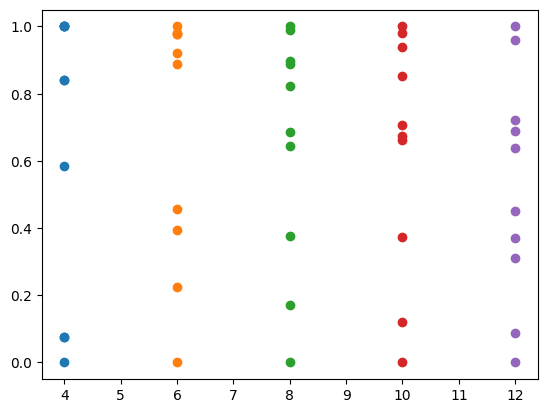

In [ ]:
eL = [4, 6, 8, 10, 12]
for L in eL:
    H = Ham(1, 1, 0.5, 0.5, L)
    E, psi0 = lg.eigsh(H, k=10, which='SA')
    E -= np.min(E)
    E /= np.abs(np.max(E) - np.min(E))
    
    # energy
    plt.scatter(np.array([L] * len(E)), E)

    # magnetization profile
plt.show()